# Week 2 — Checkpoint 1: Descriptive Statistics for Groups
### Dataset: `cars.csv` (turbo.az — car sale listings)

https://www.kaggle.com/datasets/sehriyarmemmedli/turboaz-cars-project

**Goal:** Clean the dataset and compute group-level descriptive statistics (mean, median, std, distribution shape) before moving on to formal hypothesis testing.

**Important note:** Before running statistical tests (t-test, ANOVA, etc.), it's essential to confirm the dataset is **clean** — dirty data (duplicates, mixed currencies, inconsistent units) can fundamentally invalidate statistical conclusions. Most of this checkpoint is dedicated to exactly this cleaning work.

## 1. Loading the dataset and initial look

The file is large (~950 MB, 650K+ rows) — so I only select the columns needed for the analysis (`usecols`) to save memory.

In [23]:
import pandas as pd
import numpy as np
from scipy.stats import skew

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 150)

cols = [
    "id_x", "car_rel_url_x", "datetime_scrape", "price_x", "currency_x", "city",
    "production_year", "engine_displacement_num", "kilometrage_num", "Marka", "Model",
    "Sürətlər qutusu", "Vəziyyəti", "Ötürücü", "Ban növü", "views"
]

df = pd.read_csv("cars.csv", usecols=cols, parse_dates=["datetime_scrape"])
print("Initial shape:", df.shape)
df.head()


Initial shape: (653721, 16)


,id_x,car_rel_url_x,datetime_scrape,price_x,currency_x,city,production_year,engine_displacement_num,kilometrage_num,views,Ban növü,Marka,Model,Sürətlər qutusu,Vəziyyəti,Ötürücü
0,3c234145-d57a-4ad6-9448-d43810fc3392,/autos/8748840-hyundai-i30,2024-09-13 20:32:19.751157+00,15000.0,AZN,bakı,2008,1.6,270000,492,"Hetçbek, 5 qapı",Hyundai,i30,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Ön
1,c74ea36f-6be1-4de4-926d-e117197dcf00,/autos/8475807-lada-vaz-niva-travel,2024-09-13 20:32:19.751157+00,23700.0,AZN,bakı,2024,1.7,0,60189,"Offroader / SUV, 5 qapı",LADA (VAZ),Niva Travel,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Tam
2,9cefceb0-024d-4581-a869-a3c2c68a9f95,/autos/8739686-toyota-land-cruiser,2024-09-13 20:32:19.751157+00,35600.0,$,bakı,2011,4.0,164750,2473,"Offroader / SUV, 5 qapı",Toyota,Land Cruiser,Avtomat,"Vuruğu yoxdur, rənglənməyib",Tam
3,459cc337-fb63-48de-9694-41554923d311,/autos/8712597-hyundai-elantra,2024-09-13 20:32:19.751157+00,26700.0,AZN,bakı,2018,2.0,126000,3727,Sedan,Hyundai,Elantra,Avtomat,"Vuruğu yoxdur, rənglənməyib",Ön
4,6c5ee8d8-1c6f-4fad-a694-957a4c43c25d,/autos/8674773-toyota-prius,2024-09-13 20:32:19.751157+00,10500.0,AZN,bakı,2007,1.5,354000,446,Liftbek,Toyota,Prius,Variator,"Vuruğu yoxdur, rənglənməyib",Ön


In [24]:
df.tail()

,id_x,car_rel_url_x,datetime_scrape,price_x,currency_x,city,production_year,engine_displacement_num,kilometrage_num,views,Ban növü,Marka,Model,Sürətlər qutusu,Vəziyyəti,Ötürücü
653716,16caa803-a546-455b-81ff-bc20868c2136,/autos/9081944-toyota-prius,2025-01-05 20:15:21.051803,10800.0,AZN,bakı,2008,1.5,320000,210,Liftbek,Toyota,Prius,Variator,"Vuruğu yoxdur, rənglənməyib",Ön
653717,2a26a6c1-8914-4b68-abb4-1fbd12ced7bc,/autos/9081939-uaz-hunter,2025-01-05 20:15:21.051803,9500.0,AZN,göygöl,2011,2.9,155000,1195,"Offroader / SUV, 5 qapı",UAZ,Hunter,Mexaniki,"Vuruğu yoxdur, rənglənməyib",Tam
653718,feb75615-0131-4d6f-b009-cc02faea4e01,/autos/9055034-hyundai-elantra,2025-01-05 20:15:21.051803,25400.0,AZN,bakı,2018,2.0,77926,1120,Sedan,Hyundai,Elantra,Avtomat,"Vuruğu yoxdur, rənglənməyib",Ön
653719,e5f8e957-5543-42be-b30f-78723ce551f9,/autos/9065903-jeep-grand-cherokee,2025-01-05 20:15:21.051803,10600.0,AZN,kürdəmir,1999,4.7,250000,1320,"Offroader / SUV, 5 qapı",Jeep,Grand Cherokee,Avtomat,"Vuruğu yoxdur, rənglənməyib",Tam
653720,a59362fe-117b-4b1c-bd43-636f1469cdbb,/autos/9077844-land-rover-defender,2025-01-05 20:15:21.051803,128500.0,$,bakı,2023,3.0,19000,2239,"Offroader / SUV, 5 qapı",Land Rover,Defender,Avtomat,"Vuruğu yoxdur, rənglənməyib",Tam


## 2. Critical cleaning step 1 — Removing repeated scrapes (duplicates)

**Problem:** This dataset was built by **re-scraping the same listings** on different dates — `car_rel_url_x` is each listing's unique address, but the same listing was re-scraped multiple times while it stayed active on the site (to track price/status updates).

**Why it matters:** If we run statistical tests without removing these repeats, the same car gets counted as multiple "separate observations" — this violates the statistical **independence assumption** and invalidates tests like t-test/ANOVA (artificially inflating the sample size and potentially producing artificially small p-values).

In [25]:
print("Total rows (all scrapes):", len(df))
print("Unique listings (car_rel_url_x):", df["car_rel_url_x"].nunique())
print(f"On average, each listing was scraped {len(df)/df['car_rel_url_x'].nunique():.1f} times")


Total rows (all scrapes): 653721
Unique listings (car_rel_url_x): 154030
On average, each listing was scraped 4.2 times


In [26]:
# Keep only the MOST RECENT scrape per listing (the most up-to-date price/status)
df_dedup = df.sort_values("datetime_scrape").drop_duplicates(subset="car_rel_url_x", keep="last").copy()
print("After removing duplicates:", df_dedup.shape)


After removing duplicates: (154030, 16)


## 3. Critical cleaning step 2 — Standardizing mixed currencies

**Problem:** The `currency_x` column contains **3 different currencies** (AZN, $, €) — the same `price_x` number means a completely different amount depending on the currency. Computing a mean/median without accounting for this produces a meaningless result (e.g. "23,700 AZN" and "23,700 dollars" would be treated as the same number, even though the latter is ~1.7x more expensive).

In [27]:
print(df_dedup["currency_x"].value_counts())


currency_x
AZN    133998
$       19788
€         244
Name: count, dtype: int64


In [28]:
# Converting everything to AZN using a fixed exchange rate
# AZN is officially pegged to USD: 1 USD = 1.70 AZN
# For EUR/AZN, using the approximate 2024 market average rate: ~1.85 AZN
exchange_rate = {"AZN": 1.0, "$": 1.70, "€": 1.85}

df_dedup["price_azn"] = df_dedup["price_x"] * df_dedup["currency_x"].map(exchange_rate)
df_dedup[["price_x", "currency_x", "price_azn"]].sample(5, random_state=1)


,price_x,currency_x,price_azn
647307,9500.0,AZN,9500.0
37521,12200.0,AZN,12200.0
489536,49500.0,AZN,49500.0
171428,24200.0,AZN,24200.0
592026,23700.0,$,40290.0


**Note (limitation):** This fixed rate is applied uniformly across the whole dataset, whereas the real market rate could fluctuate slightly over time. This is a simplifying assumption with minimal impact on accuracy (AZN-USD is officially pegged, and EUR makes up only ~0.9% of the dataset).

## 4. Critical cleaning step 3 — Removing non-car vehicles

**Problem:** Looking at `Ban növü` (body type), the dataset includes not just passenger cars but also **motorcycles, mopeds, trucks, buses, and quad bikes**. Their price dynamics are entirely different from passenger cars (e.g. comparing a 500 AZN moped with a passenger car in the same "group" makes no sense).

In [29]:
exclude_body_types = ["Yük maşını", "Motosiklet", "Avtobus", "Moped", "Kvadrosikl", "Dartqı", "Mikroavtobus"]

before = len(df_dedup)
df_clean = df_dedup[~df_dedup["Ban növü"].isin(exclude_body_types)].copy()
removed = before - len(df_clean)
print(f"Removed non-passenger-car vehicles: {removed} ({removed/before*100:.2f}%)")
print("Resulting shape:", df_clean.shape)


Removed non-passenger-car vehicles: 4517 (2.93%)
Resulting shape: (149513, 17)


## 5. Sanity check — prices impossible in the real market

After conversion, a small number of rows remain below 1,000 AZN (based on the Week 1 experience, these are typically data-entry errors or symbolic "negotiable" placeholder prices).

In [30]:
print("Rows with price_azn < 1000:", (df_clean["price_azn"] < 1000).sum())
df_clean = df_clean[df_clean["price_azn"] >= 1000].copy()
print("Final shape after sanity check:", df_clean.shape)


Rows with price_azn < 1000: 35
Final shape after sanity check: (149478, 17)


## 6. Descriptive statistics by group

On the cleaned dataset, I now compute **mean, median, standard deviation, and distribution shape (skewness)** for 3 key grouping variables — these will form the basis of the hypothesis tests I build in Checkpoint 2.

### 6.1 Price statistics by gearbox type (`Sürətlər qutusu`)

In [31]:
gearbox_stats = df_clean.groupby("Sürətlər qutusu")["price_azn"].agg(
    count="count", mean="mean", median="median", std="std", skewness=lambda x: skew(x)
).round(2)
gearbox_stats


,count,mean,median,std,skewness
Sürətlər qutusu,,,,,
Avtomat,98161,30022.91,22000.0,34052.92,6.28
Mexaniki,37161,10567.18,8900.0,8188.46,14.31
Reduktor,1844,66557.07,54400.0,49360.83,4.41
Robot,1527,34379.01,26800.0,35486.93,7.47
Variator,10785,25172.46,19400.0,18957.29,2.60


### 6.2 Price statistics by drivetrain type (`Ötürücü` — front/rear/all-wheel)

In [32]:
drivetrain_stats = df_clean.groupby("Ötürücü")["price_azn"].agg(
    count="count", mean="mean", median="median", std="std", skewness=lambda x: skew(x)
).round(2)
drivetrain_stats


,count,mean,median,std,skewness
Ötürücü,,,,,
Arxa,41295,19369.09,12800.0,21494.14,7.55
Tam,29611,48971.41,32000.0,54558.44,3.93
Ön,78572,19555.81,16800.0,12498.32,2.50


### 6.3 Price statistics for the top 5 most common brands

In [33]:
top5_brands = df_clean["Marka"].value_counts().head(5).index.tolist()
print("Top 5 most common brands:", top5_brands)

brand_stats = (
    df_clean[df_clean["Marka"].isin(top5_brands)]
    .groupby("Marka")["price_azn"]
    .agg(count="count", mean="mean", median="median", std="std", skewness=lambda x: skew(x))
    .loc[top5_brands]
    .round(2)
)
brand_stats


Top 5 most common brands: ['Mercedes', 'Hyundai', 'Kia', 'Toyota', 'LADA (VAZ)']


,count,mean,median,std,skewness
Marka,,,,,
Mercedes,25307,25649.69,14300.0,37616.09,5.97
Hyundai,19658,23863.66,22700.0,9818.15,2.03
Kia,14619,25764.70,24500.0,11731.08,1.08
Toyota,14388,30287.38,23200.0,22716.52,2.38
LADA (VAZ),12859,7263.76,6100.0,4728.34,2.20


## 7. Visual check of distribution shape

Confirming the skewness numbers visually.

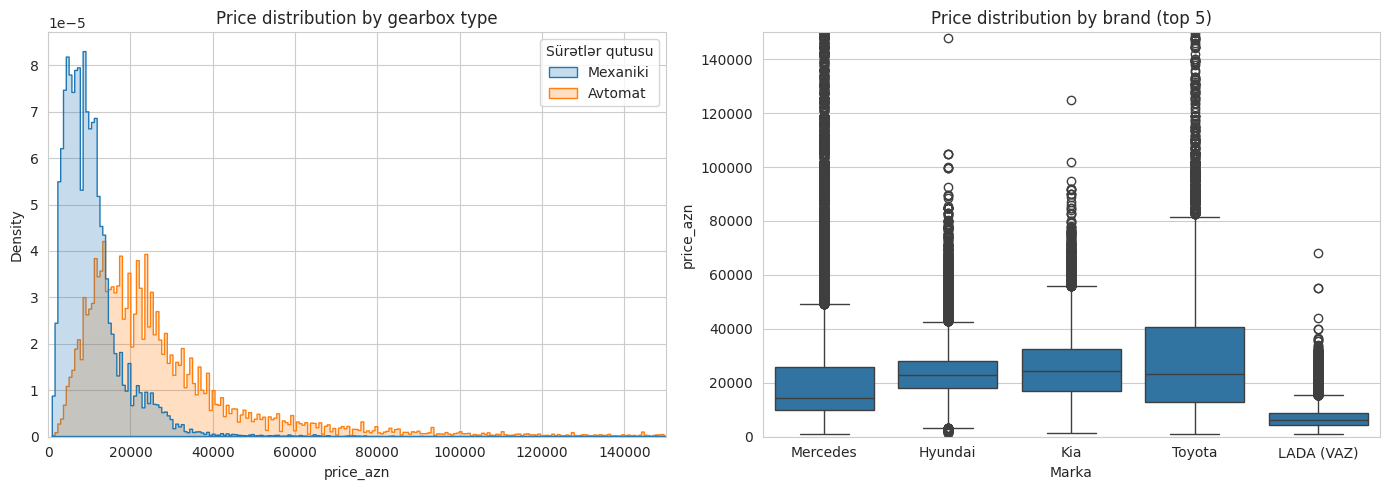

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_clean, x="price_azn", hue="Sürətlər qutusu",
             element="step", stat="density", common_norm=False, ax=axes[0],
             hue_order=["Mexaniki", "Avtomat"] if "Mexaniki" in df_clean["Sürətlər qutusu"].unique() else None)
axes[0].set_xlim(0, 150000)
axes[0].set_title("Price distribution by gearbox type")

sns.boxplot(data=df_clean[df_clean["Marka"].isin(top5_brands)], x="Marka", y="price_azn",
            order=top5_brands, ax=axes[1])
axes[1].set_ylim(0, 150000)
axes[1].set_title("Price distribution by brand (top 5)")

plt.tight_layout()
plt.show()


## Checkpoint 1 — Summary

**Cleaning steps applied:**
1. Removed duplicate scrapes (reduced from 653,721 rows down to 154,030 unique listings) — essential for preserving the statistical independence assumption.
2. Standardized 3 different currencies (AZN/$/€) to AZN using a fixed exchange rate.
3. Removed non-passenger-car vehicles (motorcycles, mopeds, trucks, etc., ~2.9%).
4. Removed prices impossible in the real market (below 1000 AZN) via a sanity check.
5. Final clean dataset: **149,478 unique passenger car listings**.

**Key observations (descriptive statistics):**
- All price distributions are **strongly right-skewed** (skewness ranging from 1.1 to 14.3) — meaning the **normality assumption** must be carefully checked in future hypothesis tests.
- Cars with `Avtomat` (automatic) gearbox have a median price (22,000 AZN) that is **~2.5x higher** than `Mexaniki` (manual, 8,900 AZN).
- `Tam` (all-wheel drive) cars have a substantially higher median price (32,000 AZN) than `Ön`/`Arxa` (front/rear) — a good candidate for an additional hypothesis.
- By brand: `LADA (VAZ)` has the lowest median price (6,100 AZN), while the other 4 brands cluster relatively closer together (14,300–24,500 AZN) — a good candidate for a multi-group comparison (ANOVA + Bonferroni).
